# 🌌 ExoProfiler — Comprensión inicial del dataset

## 1. Data Understanding

Este notebook tiene como objetivo realizar una primera exploración del dataset de exoplanetas utilizado en el proyecto ExoProfiler.

En esta fase se analizarán:

- Las dimensiones del dataset.
- La estructura y significado de las variables.
- Los tipos de datos.
- La presencia de valores nulos.
- La existencia de registros duplicados.
- La relevancia inicial de las variables para el análisis de clustering.

El objetivo final es comprender la calidad y estructura de los datos antes de realizar el análisis exploratorio y el preprocesamiento.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_PATH = "../data/raw/exoplanets.csv"

df = pd.read_csv(
    DATA_PATH,
    comment="#" #Ignora las líneas que comiencen por #, porque son comentarios/metadatos y no forman parte de la tabla.
)

df.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,pl_refname,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_radj,pl_radjerr1,pl_radjerr2,pl_radjlim,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_bmasselim,pl_bmassj,pl_bmassjerr1,pl_bmassjerr2,pl_bmassjlim,pl_bmassprov,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccenlim,pl_insol,pl_insolerr1,pl_insolerr2,pl_insollim,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtlim,ttv_flag,st_refname,st_spectype,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_rad,st_raderr1,st_raderr2,st_radlim,st_mass,st_masserr1,st_masserr2,st_masslim,st_met,st_meterr1,st_meterr2,st_metlim,st_metratio,st_logg,st_loggerr1,st_loggerr2,st_logglim,sy_refname,rastr,ra,decstr,dec,sy_dist,sy_disterr1,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,AU Mic b,AU Mic,1,1,4,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,<a refstr=MALLORQUIN_ET_AL_2024 href=https://u...,8.463446,0.000005,-0.000005,0.0,0.0700,0.0060,-0.0070,0.0,4.79,0.29,-0.29,0.0,0.427336,0.025872,-0.025872,0.0,8.99,2.61,-2.67,0.0,0.028286,0.008212,-0.008401,0.0,Mass,0.070,0.0900,-0.040,0.0,NaN,NaN,NaN,NaN,554.8,31.6,-32.0,0.0,1.0,<a refstr=MALLORQUIN_ET_AL_2024 href=https://u...,M1 V,3540.0,120.0,-110.0,0.0,0.862,0.052,-0.052,0.0,0.635,0.04,-0.07,0.0,0.01,0.06,-0.06,0.0,[Fe/H],4.37,0.08,-0.10,0.0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,20h45m09.87s,311.291137,-31d20m32.82s,-31.342450,9.7221,0.004625,-0.004625,8.810,0.100,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2026-03-05,2024-09,2026-03-05
1,AU Mic c,AU Mic,1,1,4,Transit,2021,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,<a refstr=MALLORQUIN_ET_AL_2024 href=https://u...,18.859023,0.000022,-0.000024,0.0,0.1190,0.0110,-0.0110,0.0,2.79,0.18,-0.17,0.0,0.248908,0.016059,-0.015166,0.0,14.46,3.24,-3.42,0.0,0.045496,0.010194,-0.010761,0.0,Mass,0.180,0.0800,-0.070,0.0,NaN,NaN,NaN,NaN,424.7,24.2,-24.5,0.0,1.0,<a refstr=MALLORQUIN_ET_AL_2024 href=https://u...,M1 V,3540.0,120.0,-110.0,0.0,0.862,0.052,-0.052,0.0,0.635,0.04,-0.07,0.0,0.01,0.06,-0.06,0.0,[Fe/H],4.37,0.08,-0.10,0.0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,20h45m09.87s,311.291137,-31d20m32.82s,-31.342450,9.7221,0.004625,-0.004625,8.810,0.100,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2026-03-05,2024-09,2026-03-05
2,BD+05 4868 A b,BD+05 4868 A,1,2,1,Transit,2025,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,<a refstr=HON_ET_AL_2025 href=https://ui.adsab...,1.271869,0.000001,-0.000001,0.0,0.0208,0.0003,-0.0003,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.20,NaN,NaN,1.0,0.019507,NaN,NaN,1.0,Mass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1820.0,45.0,-45.0,0.0,0.0,<a refstr=HON_ET_AL_2025 href=https://ui.adsab...,K V,4596.0,65.0,-64.0,0.0,0.690,0.020,-0.020,0.0,0.700,0.02,-0.02,0.0,-0.05,0.08,-0.05,0.0,[Fe/H],4.60,0.03,-0.02,0.0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,21h47m26.74s,326.861404,+06d36m19.15s,6.605319,43.5687,0.097500,-0.097100,10.158,0.010,-0.010,7.448,0.026,-0.026,9.84152,0.000476,-0.000476,2025-03-21,2025-05,2025-03-21
3,BD-14 3065 b,BD-14 3065 A,1,3,1,Transit,2024,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,<a refstr=SUBJAK_ET_AL_2024 href=https://ui.ad...,4.288973,0.000005,-0.000005,0.0,0.0656,0.0026,-0.0026,0.0,21.59,1.05,-1.05,0.0,1.926000,0.094000,-0.094000,0.0,3932.00,290.00,-280.00,0.0,12.370000,0.920000,-0.870000,0.0,Mass,0.066,0.0098,-0.011,0.0,NaN,NaN,NaN,NaN,2001.0,31.0,-31.0,0.0,0.0,<a refstr=SUBJAK_ET_AL_2024 href=https://ui.ad...,NaN,6935.0,90.0,-90.0,0.0,2.350,0.080,-0.080,0.0,1.410,0.05,-0.05,0.0,-0.34,0.05,-0.05,0.0,[Fe/H],3.85,0.03,-0.03,0.0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,10h14m40.72s,153.669669,-15d38m34.21s,-15.642837,58

In [3]:
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de filas: 910
Número de columnas: 92


In [4]:
df.columns.tolist()

['pl_name',
 'hostname',
 'default_flag',
 'sy_snum',
 'sy_pnum',
 'discoverymethod',
 'disc_year',
 'disc_facility',
 'soltype',
 'pl_controv_flag',
 'pl_refname',
 'pl_orbper',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbperlim',
 'pl_orbsmax',
 'pl_orbsmaxerr1',
 'pl_orbsmaxerr2',
 'pl_orbsmaxlim',
 'pl_rade',
 'pl_radeerr1',
 'pl_radeerr2',
 'pl_radelim',
 'pl_radj',
 'pl_radjerr1',
 'pl_radjerr2',
 'pl_radjlim',
 'pl_bmasse',
 'pl_bmasseerr1',
 'pl_bmasseerr2',
 'pl_bmasselim',
 'pl_bmassj',
 'pl_bmassjerr1',
 'pl_bmassjerr2',
 'pl_bmassjlim',
 'pl_bmassprov',
 'pl_orbeccen',
 'pl_orbeccenerr1',
 'pl_orbeccenerr2',
 'pl_orbeccenlim',
 'pl_insol',
 'pl_insolerr1',
 'pl_insolerr2',
 'pl_insollim',
 'pl_eqt',
 'pl_eqterr1',
 'pl_eqterr2',
 'pl_eqtlim',
 'ttv_flag',
 'st_refname',
 'st_spectype',
 'st_teff',
 'st_tefferr1',
 'st_tefferr2',
 'st_tefflim',
 'st_rad',
 'st_raderr1',
 'st_raderr2',
 'st_radlim',
 'st_mass',
 'st_masserr1',
 'st_masserr2',
 'st_masslim',
 'st_met',
 'st_me

## 2. Estructura de las variables

El dataset contiene información de diferentes niveles relacionados con cada exoplaneta.

Los nombres de las variables utilizan prefijos que permiten identificar el tipo de información:

- `pl_`: propiedades del planeta.
- `st_`: propiedades de la estrella anfitriona.
- `sy_`: propiedades generales del sistema planetario.
- `disc_`: información relacionada con el descubrimiento.

Además, algunas variables incluyen sufijos relacionados con errores de medición, límites o referencias bibliográficas.

Estas variables deberán analizarse cuidadosamente antes de seleccionar las características utilizadas para clustering.

In [5]:
#Inventario de columnas
column_info = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "nulos": df.isnull().sum().values,
    "porcentaje_nulos": (
        df.isnull().mean().values * 100
    ).round(2),
    "valores_unicos": df.nunique().values
})

column_info

,variable,dtype,nulos,porcentaje_nulos,valores_unicos
0,pl_name,object,0,0.00,910
1,hostname,object,0,0.00,765
2,default_flag,int64,0,0.00,1
3,sy_snum,int64,0,0.00,3
4,sy_pnum,int64,0,0.00,6
5,discoverymethod,object,0,0.00,2
6,disc_year,int64,0,0.00,9
7,disc_facility,object,0,0.00,1
8,soltype,object,0,0.00,2
9,pl_controv_flag,int64,0,0.00,2


In [6]:
#Nulos

column_info.sort_values(
    by="porcentaje_nulos",
    ascending=False
).head(30)

,variable,dtype,nulos,porcentaje_nulos,valores_unicos
50,st_spectype,object,560,61.54,116
37,pl_orbeccenerr1,float64,555,60.99,133
38,pl_orbeccenerr2,float64,555,60.99,117
42,pl_insolerr2,float64,539,59.23,228
41,pl_insolerr1,float64,539,59.23,238
43,pl_insollim,float64,524,57.58,1
40,pl_insol,float64,524,57.58,374
33,pl_bmassjerr2,float64,342,37.58,293
32,pl_bmassjerr1,float64,342,37.58,296
29,pl_bmasseerr2,float64,342,37.58,288


In [7]:
#Duplicados

duplicados = df.duplicated().sum()

print(f"Filas duplicadas completas: {duplicados}")

Filas duplicadas completas: 0


In [8]:
#¿Tenemos exactamente una fila por planeta?

df["pl_name"].nunique()

910

In [9]:
df["pl_name"].value_counts().head(20)

pl_name
AU Mic b        1
TOI-4342 c      1
TOI-4034 b      1
TOI-406 c       1
TOI-406.01      1
TOI-4087 b      1
TOI-411 b       1
TOI-411 c       1
TOI-4127 b      1
TOI-4137 b      1
TOI-4145 A b    1
TOI-4153 b      1
TOI-4155 b      1
TOI-4156 b      1
TOI-4156 c      1
TOI-4184 b      1
TOI-4201 b      1
TOI-421 b       1
TOI-421 c       1
TOI-4214 b      1
Name: count, dtype: int64

In [10]:
#Tipos de variables

df.dtypes.value_counts()

float64    71
object     16
int64       5
Name: count, dtype: int64

In [11]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print(f"Variables numéricas: {len(numeric_cols)}")
print(f"Variables no numéricas: {len(categorical_cols)}")

Variables numéricas: 76
Variables no numéricas: 16


## 3. Selección conceptual inicial de variables

El dataset original contiene un gran número de variables que representan distintos tipos de información: propiedades físicas de los planetas, características orbitales, datos de las estrellas anfitrionas, información sobre el descubrimiento, referencias bibliográficas e incertidumbres asociadas a las mediciones.

Para un modelo de clustering no es conveniente utilizar automáticamente todas las columnas disponibles. Las variables utilizadas deben estar relacionadas con el fenómeno que se quiere estudiar, ya que los algoritmos de clustering agrupan las observaciones en función de la similitud entre sus características.

En este proyecto buscamos descubrir posibles **familias de exoplanetas según sus características físicas, orbitales y su entorno estelar**.

Por este motivo, se realiza primero una selección conceptual de variables potencialmente relevantes.

Esta selección es únicamente preliminar. Las variables candidatas serán posteriormente evaluadas mediante el análisis exploratorio de datos (EDA), teniendo en cuenta:

- Su significado científico.
- La cantidad de valores disponibles.
- La presencia de valores nulos.
- Sus distribuciones.
- La existencia de valores extremos.
- La posible redundancia o correlación con otras variables.

La selección definitiva de características se realizará después de este análisis.

### 3.1 Variables candidatas según su significado

Se han identificado inicialmente dos grupos de variables potencialmente relevantes:

1. **Variables planetarias y orbitales:** describen directamente las propiedades físicas y orbitales del exoplaneta.

2. **Variables estelares:** describen características de la estrella anfitriona y permiten estudiar si el entorno estelar aporta información relevante a la formación de los grupos.

Estas variables se consideran **candidatas**, no variables definitivas del modelo.

Su inclusión final dependerá de los resultados obtenidos durante el análisis exploratorio.

In [12]:
# Variables relacionadas directamente con las propiedades
# físicas y orbitales de los exoplanetas.
planet_features = [
    "pl_orbper",      # Periodo orbital del planeta (días).
    "pl_orbsmax",     # Semieje mayor: distancia orbital respecto a su estrella (UA).
    "pl_rade",        # Radio del planeta expresado en radios terrestres.
    "pl_bmasse",      # Masa del planeta expresada en masas terrestres.
    "pl_orbeccen",    # Excentricidad: indica cómo de circular o elíptica es la órbita.
    "pl_insol",       # Insolación recibida respecto a la que recibe la Tierra.
    "pl_eqt"          # Temperatura de equilibrio estimada del planeta (K).
]

# Variables relacionadas con las propiedades físicas
# de la estrella anfitriona del planeta.
stellar_features = [
    "st_teff",        # Temperatura efectiva de la estrella (K).
    "st_rad",         # Radio de la estrella respecto al radio del Sol.
    "st_mass",        # Masa de la estrella respecto a la masa del Sol.
    "st_met",         # Metalicidad de la estrella.
    "st_logg"         # Gravedad superficial de la estrella.
]

# Unimos ambos grupos para poder analizarlos conjuntamente.
candidate_features = planet_features + stellar_features

# Mostramos el número total de variables candidatas.
print(f"Número inicial de variables candidatas: {len(candidate_features)}")

# Mostramos sus nombres para comprobar que la selección es correcta.
candidate_features

Número inicial de variables candidatas: 12


['pl_orbper',
 'pl_orbsmax',
 'pl_rade',
 'pl_bmasse',
 'pl_orbeccen',
 'pl_insol',
 'pl_eqt',
 'st_teff',
 'st_rad',
 'st_mass',
 'st_met',
 'st_logg']

### 3.2 Comprobación de las variables seleccionadas

Antes de continuar con el análisis se comprueba que todas las variables candidatas existen realmente en el dataset.

Esta validación evita errores posteriores provocados por nombres incorrectos o columnas inexistentes y permite verificar que la selección conceptual coincide con la estructura real de los datos.

In [13]:
# Buscamos si alguna de las variables candidatas
# no está presente entre las columnas del dataset.
missing_features = [
    column
    for column in candidate_features
    if column not in df.columns
]

# Si la lista está vacía, significa que todas las variables existen.
if not missing_features:
    print("Todas las variables candidatas existen en el dataset.")
else:
    print("Variables no encontradas:")
    print(missing_features)

Todas las variables candidatas existen en el dataset.


## 4. Análisis de disponibilidad y valores nulos

Una variable puede ser relevante desde el punto de vista científico, pero su utilidad para el clustering también depende de la cantidad de observaciones disponibles.

Los algoritmos de clustering utilizados posteriormente requieren trabajar con datos numéricos completos, por lo que es necesario estudiar la presencia de valores ausentes antes de seleccionar las características definitivas.

En esta fase no se eliminarán ni imputarán valores nulos.

El objetivo es únicamente analizar su distribución y determinar qué variables presentan una cobertura suficiente y cuáles requieren una estrategia específica de tratamiento.

In [14]:
# Calculamos el número total de observaciones del dataset.
total_rows = len(df)

# Creamos una tabla resumen para estudiar la disponibilidad
# de datos de cada variable candidata.
candidate_summary = pd.DataFrame({
    
    # Tipo de dato almacenado en cada variable.
    "tipo_dato": df[candidate_features].dtypes,
    
    # Número de valores disponibles (no nulos).
    "valores_disponibles": df[candidate_features].notna().sum(),
    
    # Número de valores ausentes.
    "nulos": df[candidate_features].isna().sum(),
    
    # Porcentaje de valores ausentes respecto al total.
    "porcentaje_nulos": (
        df[candidate_features].isna().mean() * 100
    ).round(2),
    
    # Porcentaje de observaciones que sí contienen información.
    "cobertura": (
        df[candidate_features].notna().mean() * 100
    ).round(2)
})

# Ordenamos las variables desde la que tiene mayor cobertura
# hasta la que presenta más información ausente.
candidate_summary = candidate_summary.sort_values(
    by="cobertura",
    ascending=False
)

candidate_summary

,tipo_dato,valores_disponibles,nulos,porcentaje_nulos,cobertura
pl_orbper,float64,907,3,0.33,99.67
st_rad,float64,905,5,0.55,99.45
pl_rade,float64,897,13,1.43,98.57
st_teff,float64,885,25,2.75,97.25
st_logg,float64,821,89,9.78,90.22
st_mass,float64,787,123,13.52,86.48
pl_orbsmax,float64,704,206,22.64,77.36
st_met,float64,685,225,24.73,75.27
pl_eqt,float64,670,240,26.37,73.63
pl_orbeccen,float64,623,287,31.54,68.46


### 4.1 Visualización de la cobertura de las variables candidatas

Se representa gráficamente el porcentaje de datos disponibles para cada variable candidata.

Esta visualización permite identificar rápidamente qué características presentan una buena cobertura y cuáles podrían limitar significativamente el número de planetas disponibles para el análisis.

Una baja cobertura no implica automáticamente que una variable deba eliminarse. Su relevancia científica y las posibles estrategias de tratamiento deberán evaluarse antes de tomar una decisión definitiva.

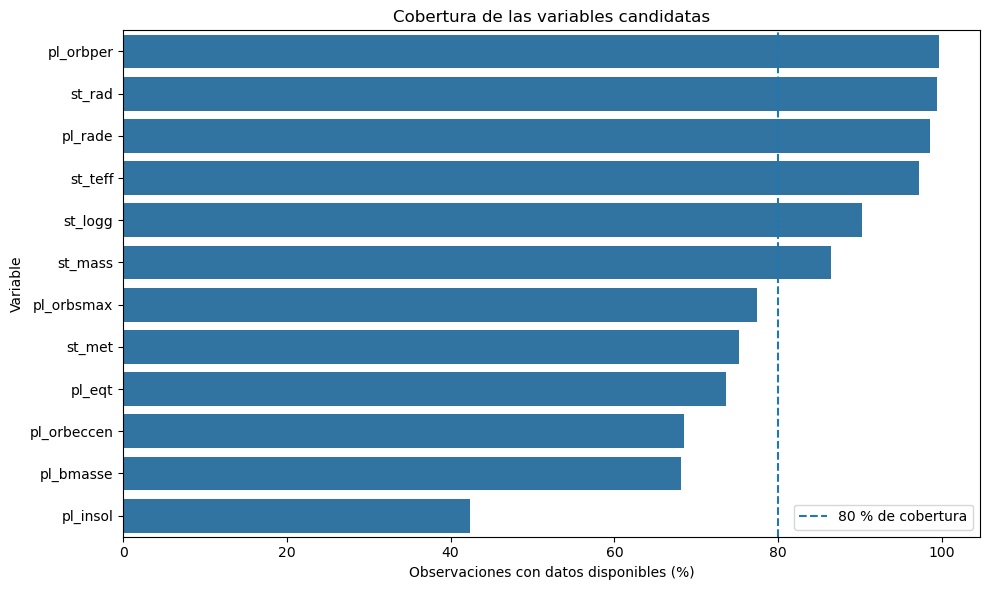

In [15]:
# Creamos una figura con un tamaño suficiente para
# visualizar claramente todas las variables.
plt.figure(figsize=(10, 6))

# Representamos el porcentaje de cobertura de cada variable.
sns.barplot(
    data=candidate_summary.reset_index(),
    x="cobertura",
    y="index"
)

# Añadimos una línea de referencia en el 80 %.
# No representa un criterio automático de eliminación,
# sino una ayuda visual para interpretar la disponibilidad.
plt.axvline(
    x=80,
    linestyle="--",
    label="80 % de cobertura"
)

# Añadimos títulos descriptivos.
plt.title("Cobertura de las variables candidatas")
plt.xlabel("Observaciones con datos disponibles (%)")
plt.ylabel("Variable")

# Mostramos la leyenda y el gráfico.
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Disponibilidad conjunta de las variables

Además de estudiar los valores nulos de cada variable individualmente, es necesario conocer cuántos exoplanetas disponen simultáneamente de información completa para todas las características candidatas.

Este análisis es especialmente importante para clustering, ya que eliminar todas las filas que contienen algún valor nulo podría reducir considerablemente el tamaño del dataset y provocar una pérdida importante de información.

Por este motivo, antes de decidir cualquier estrategia de tratamiento se analiza el impacto que tendría trabajar únicamente con casos completos.

In [16]:
# Seleccionamos únicamente las variables candidatas
# y eliminamos temporalmente las filas que contienen
# al menos un valor nulo.
complete_cases = df[candidate_features].dropna()

# Calculamos cuántos planetas conservaríamos.
n_complete = len(complete_cases)

# Calculamos qué porcentaje representan respecto al dataset original.
percentage_complete = (n_complete / len(df)) * 100

print(f"Planetas totales: {len(df)}")
print(f"Planetas con todas las variables disponibles: {n_complete}")
print(
    f"Porcentaje conservado: "
    f"{percentage_complete:.2f} %"
)

Planetas totales: 910
Planetas con todas las variables disponibles: 249
Porcentaje conservado: 27.36 %


### Conclusión provisional sobre los valores ausentes

El análisis de cobertura permite comprobar que las variables candidatas presentan distintos niveles de disponibilidad.

No se aplicará todavía ninguna estrategia de eliminación o imputación, ya que hacerlo en esta fase podría provocar una pérdida innecesaria de información o introducir valores artificiales que afecten a las distancias utilizadas posteriormente por los algoritmos de clustering.

En las siguientes etapas del EDA se analizarán conjuntamente:

- La relevancia científica de cada variable.
- Su porcentaje de cobertura.
- Su distribución.
- La presencia de valores extremos.
- Su relación y posible redundancia con otras características.

A partir de estos resultados se decidirá qué variables conservar y qué estrategia de tratamiento aplicar.

### 4.3 Impacto acumulado de los valores nulos

El análisis anterior muestra que únicamente 249 de los 910 exoplanetas disponen de información completa para las 12 variables candidatas, lo que representa un 27,36 % del dataset original.

Eliminar directamente todas las observaciones con algún valor ausente supondría perder más del 70 % de los planetas disponibles.

Para comprender mejor esta pérdida de información, se analiza cómo disminuye progresivamente el número de observaciones completas al incorporar variables con menor cobertura.

Este análisis permitirá identificar qué características reducen especialmente el tamaño de la muestra y ayudará posteriormente a encontrar un equilibrio entre:

- La cantidad de exoplanetas disponibles.
- La riqueza de información utilizada para describirlos.
- La relevancia científica de las variables.

Este análisis no determina automáticamente qué variables deben eliminarse, sino que sirve como apoyo para la selección posterior de características.

In [17]:
# Obtenemos las variables candidatas ordenadas
# desde la que tiene mayor cobertura hasta la que tiene menor cobertura.
features_by_coverage = candidate_summary.index.tolist()

# Creamos una lista vacía donde guardaremos
# los resultados del análisis acumulativo.
coverage_impact = []

# Esta lista irá almacenando progresivamente
# las variables que incorporamos al análisis.
selected_features = []

# Recorremos las variables una a una siguiendo
# el orden de mayor a menor cobertura.
for feature in features_by_coverage:
    
    # Añadimos la nueva variable al conjunto analizado.
    selected_features.append(feature)
    
    # Contamos cuántos planetas tienen datos completos
    # para TODAS las variables incluidas hasta este momento.
    complete_rows = df[selected_features].dropna().shape[0]
    
    # Calculamos qué porcentaje del dataset original conservaríamos.
    retained_percentage = (complete_rows / len(df)) * 100
    
    # Guardamos los resultados de esta iteración.
    coverage_impact.append({
        "variable_añadida": feature,
        "numero_variables": len(selected_features),
        "planetas_disponibles": complete_rows,
        "porcentaje_conservado": round(retained_percentage, 2)
    })

# Convertimos los resultados en un DataFrame
# para poder analizarlos fácilmente.
coverage_impact_df = pd.DataFrame(coverage_impact)

coverage_impact_df

,variable_añadida,numero_variables,planetas_disponibles,porcentaje_conservado
0,pl_orbper,1,907,99.67
1,st_rad,2,905,99.45
2,pl_rade,3,894,98.24
3,st_teff,4,874,96.04
4,st_logg,5,811,89.12
5,st_mass,6,695,76.37
6,pl_orbsmax,7,627,68.90
7,st_met,8,602,66.15
8,pl_eqt,9,558,61.32
9,pl_orbeccen,10,485,53.30


#### Evolución del número de observaciones completas

El siguiente gráfico muestra cómo cambia el número de exoplanetas disponibles a medida que se incorporan progresivamente variables con menor cobertura.

Una reducción pronunciada tras añadir una determinada característica indica que esa variable limita especialmente el número de observaciones completas disponibles.

Sin embargo, esta pérdida de datos deberá valorarse conjuntamente con la relevancia científica de la variable antes de decidir su inclusión o exclusión.

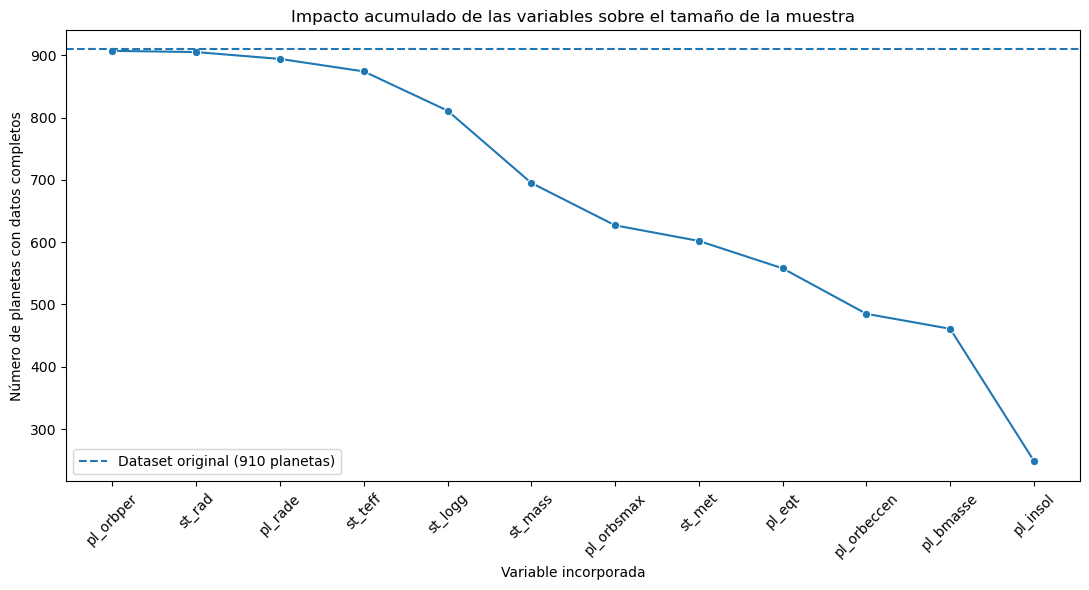

In [18]:
# Creamos una figura para visualizar cómo disminuye
# el número de planetas disponibles al añadir variables.
plt.figure(figsize=(11, 6))

# Dibujamos una línea que relaciona cada variable añadida
# con el número de observaciones completas que se conservan.
sns.lineplot(
    data=coverage_impact_df,
    x="variable_añadida",
    y="planetas_disponibles",
    marker="o"
)

# Añadimos una línea horizontal que representa
# el número total de planetas del dataset original.
plt.axhline(
    y=len(df),
    linestyle="--",
    label=f"Dataset original ({len(df)} planetas)"
)

# Añadimos títulos descriptivos.
plt.title(
    "Impacto acumulado de las variables sobre el tamaño de la muestra"
)
plt.xlabel("Variable incorporada")
plt.ylabel("Número de planetas con datos completos")

# Giramos los nombres de las variables para facilitar su lectura.
plt.xticks(rotation=45)

# Mostramos la leyenda.
plt.legend()

# Ajustamos automáticamente los elementos del gráfico.
plt.tight_layout()

# Mostramos el resultado.
plt.show()

In [19]:
# Calculamos cuántos planetas se pierden al incorporar
# cada nueva variable respecto al paso anterior.
coverage_impact_df["planetas_perdidos"] = (
    coverage_impact_df["planetas_disponibles"]
    .shift(1, fill_value=len(df))
    - coverage_impact_df["planetas_disponibles"]
)

coverage_impact_df

,variable_añadida,numero_variables,planetas_disponibles,porcentaje_conservado,planetas_perdidos
0,pl_orbper,1,907,99.67,3
1,st_rad,2,905,99.45,2
2,pl_rade,3,894,98.24,11
3,st_teff,4,874,96.04,20
4,st_logg,5,811,89.12,63
5,st_mass,6,695,76.37,116
6,pl_orbsmax,7,627,68.90,68
7,st_met,8,602,66.15,25
8,pl_eqt,9,558,61.32,44
9,pl_orbeccen,10,485,53.30,73


### Conclusión provisional sobre la disponibilidad de datos

El dataset contiene 910 exoplanetas, pero la disponibilidad de información varía considerablemente entre las características analizadas.

Variables como `pl_orbper`, `st_rad`, `pl_rade` y `st_teff` presentan una cobertura superior al 97 %, mientras que otras características científicamente relevantes tienen una disponibilidad significativamente menor.

El caso más destacado es `pl_insol`, para la que solo se dispone de información en el 42,42 % de las observaciones.

Al exigir datos completos simultáneamente para las 12 variables candidatas, el conjunto disponible se reduce a 249 exoplanetas, lo que representa únicamente el 27,36 % del dataset original.

Por tanto, eliminar directamente todas las filas con valores ausentes supondría perder aproximadamente el 72,64 % de las observaciones.

Estos resultados muestran la necesidad de estudiar cuidadosamente la selección de características y el tratamiento de los valores ausentes antes del modelado.

La decisión final no se basará únicamente en el porcentaje de nulos, sino también en la relevancia científica de cada variable, su distribución, su relación con otras características y la información adicional que pueda aportar al proceso de clustering.